In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

from torchcodec.encoders import VideoEncoder
from IPython.display import Video
from IPython.display import Audio as play_audio
from torchvision.utils import make_grid

def play_video(encoded_bytes):
    return Video(data=encoded_bytes.numpy().tobytes(),
                embed=True, width=640, height=360, mimetype="video/mp4")

import matplotlib.pyplot as plt

import sys
sys.path.append('../../../')

In [2]:
import os
from pathlib import Path
from typing import Any, Callable, Optional, Union, cast

import torch
from torchvision import tv_tensors
from torchvision.transforms import v2
from torch.utils.data import DataLoader, default_collate

import numpy as np

%load_ext autoreload
%autoreload 2

from computer_vision.torch_video.data.dataset import UCF101, ConvertTCHWtoCTHW
from computer_vision.torch_video.parameter_parser import parser

DATA_MEAN=(0.43216, 0.394666, 0.37645)
DATA_STD=(0.22803, 0.22145, 0.216989)
NUM_CLASSES=101

In [41]:
data_dirpath=Path('D:/data/UCF101')
root=data_dirpath/'UCF-101'
annotation_path=data_dirpath/'UCF101TrainTestSplits-RecognitionTask'
metadata_path=data_dirpath/'metadata.pt'
class_id_path=annotation_path/"classInd.txt"


arguments= f"""-d {root} -a {annotation_path} -m {metadata_path} -c {class_id_path}
--data-fold 1 --frame-rate 8 --clip-duration 2 --step-duration 1.7 
"""
args=parser.parse_args(arguments.split())

with open(args.class_id, 'r') as file: content = file.read()
class_ids=dict([int(v) if i==0 else v for i, v in enumerate(line.split(' '))] for line in content.strip().split('\n'))

train_dataset=UCF101(root=args.data_path, annotation_path=args.annotation_path, frame_rate=args.frame_rate, 
                     clip_duration=args.clip_duration, step_duration=args.step_duration,
                     train=True, metadata_path=args.metadata_path, fold=args.data_fold, sampling_type='random', use_audio=False,
                     decoder_transforms=[v2.RandomCrop(size=args.train_crop_size),
                                         v2.Resize(args.train_resize_size)],
                     transforms=v2.Compose([
                         v2.RandomHorizontalFlip(p=args.hflip_prob),
                         v2.ToDtype(torch.float32, scale=True),
                         v2.Normalize(mean=DATA_MEAN,std=DATA_STD),
                         ConvertTCHWtoCTHW()])
                    ) 

# val_dataset=UCF101(root=args.data_path, annotation_path=args.annotation_path, frame_rate=args.frame_rate, 
#                      clip_duration=args.clip_duration, step_duration=args.step_duration,
#                      train=False, metadata_path=args.metadata_path, fold=args.data_fold, sampling_type='regular', use_audio=False,
#                      decoder_transforms=[v2.CenterCrop(size=args.train_crop_size),
#                                          v2.Resize(args.train_resize_size)],
#                      transforms=v2.Compose([
#                          v2.ToDtype(torch.float32, scale=True),
#                          v2.Normalize(mean=DATA_MEAN,std=DATA_STD),
#                          ConvertTCHWtoCTHW()])
#                     ) 


In [42]:
train_dataloader=DataLoader(train_dataset, batch_size=4, shuffle=True)
video, label, video_idx, info=next(iter(train_dataloader))
print(f"{video.shape=}, {video.dtype=} ({video.min().item():.3f},{video.max().item():.3f})")
print(f"{info=}, {label=}, {video_idx=}")
# _, ax=plt.subplots(video.shape[0],1, figsize=(10,10))
# for b in range(video.shape[0]): 
#     ax[b].imshow(make_grid(video[b].permute(1,0,2,3)).permute(1,2,0))
#     ax[b].axis('off')
# plt.tight_layout()

video.shape=torch.Size([4, 3, 16, 112, 112]), video.dtype=torch.float32 (-1.895,2.874)
info={'video_fps': tensor([8, 8, 8, 8])}, label=tensor([46, 73, 86, 78]), video_idx=tensor([4430, 7037, 8172, 7500])


## V2 Augmentation

In [43]:
# see https://docs.pytorch.org/vision/main/auto_examples/transforms/plot_cutmix_mixup.html
cutmix=v2.CutMix(num_classes=NUM_CLASSES)
mixup=v2.MixUp(num_classes=NUM_CLASSES)
cutmix_or_mixup=v2.RandomChoice([cutmix, mixup])

### MixUp

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8263988..2.1868873].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7694926..2.1156929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.716808..2.4901986].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.626159..2.4417129].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8951892..2.7652123].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8845621..2.6367831].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8263988.

video.shape=torch.Size([4, 3, 16, 112, 112]), video.dtype=torch.float32 (-1.885,2.637)
label.shape=torch.Size([4, 101]),label.dtype=torch.float32,(0.000,0.961)
info={'video_fps': tensor([8, 8, 8, 8])}, video_idx=tensor([4691, 6355, 6687, 5836])


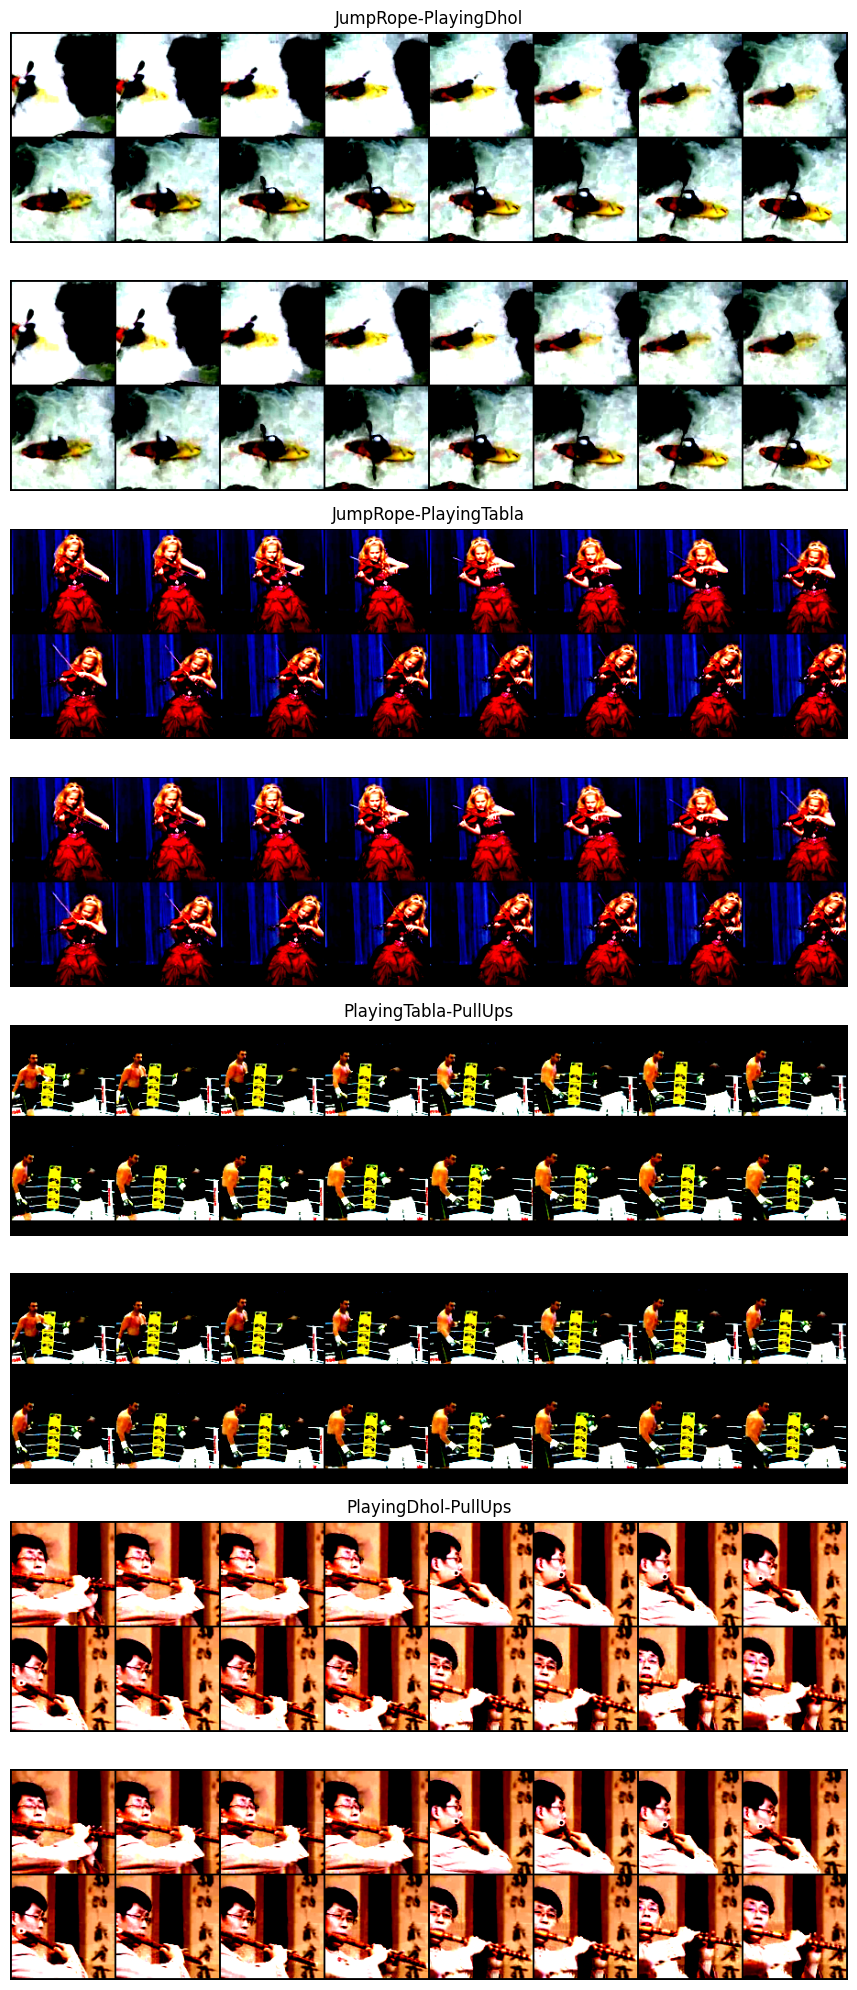

In [44]:
def collate_fn(batch):
    output=default_collate(batch)
    videos=tv_tensors.Video(output[0], dtype=output[0].dtype, device=output[0].device)
    labels=output[1] if len(output)==4 else output[2] # 4 outputs mean there is no audio
    return videos, mixup(videos, labels), output[-2:]

train_dataloader=DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
original_videos, (video, label), (video_idx, info)=next(iter(train_dataloader))
print(f"{video.shape=}, {video.dtype=} ({video.min().item():.3f},{video.max().item():.3f})")
print(f"{label.shape=},{label.dtype=},({label.min().item():.3f},{label.max().item():.3f})")
print(f"{info=}, {video_idx=}")

_, ax=plt.subplots(2*video.shape[0],1, figsize=(10,20))
for b in range(video.shape[0]): 
    label_ids=torch.nonzero(label[b]>0, as_tuple=True)[0].tolist()
    class_names=[class_ids[l] for l in label_ids]
    ax[2*b].imshow(make_grid(original_videos[b].permute(1,0,2,3)).permute(1,2,0))
    ax[2*b].axis('off')
    ax[2*b].set_title('-'.join(class_names), fontsize=12)
    ax[2*b+1].imshow(make_grid(video[b].permute(1,0,2,3)).permute(1,2,0))
    ax[2*b+1].axis('off')
    # ax[2*b+1].set_title('-'.join(class_names), fontsize=12)
plt.tight_layout()

#### CutMix

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8951892..2.8194304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8951892..2.7471397].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8263988..2.556416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8951892..2.8194304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8779917..2.8194304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8607941..2.8194304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8951892

video.shape=torch.Size([4, 3, 16, 112, 112]), video.dtype=torch.float32 (-1.895,2.819)
label.shape=torch.Size([4, 101]),label.dtype=torch.float32,(0.000,0.577)
info={'video_fps': tensor([8, 8, 8, 8])}, video_idx=tensor([6534, 8130, 7134, 3416])


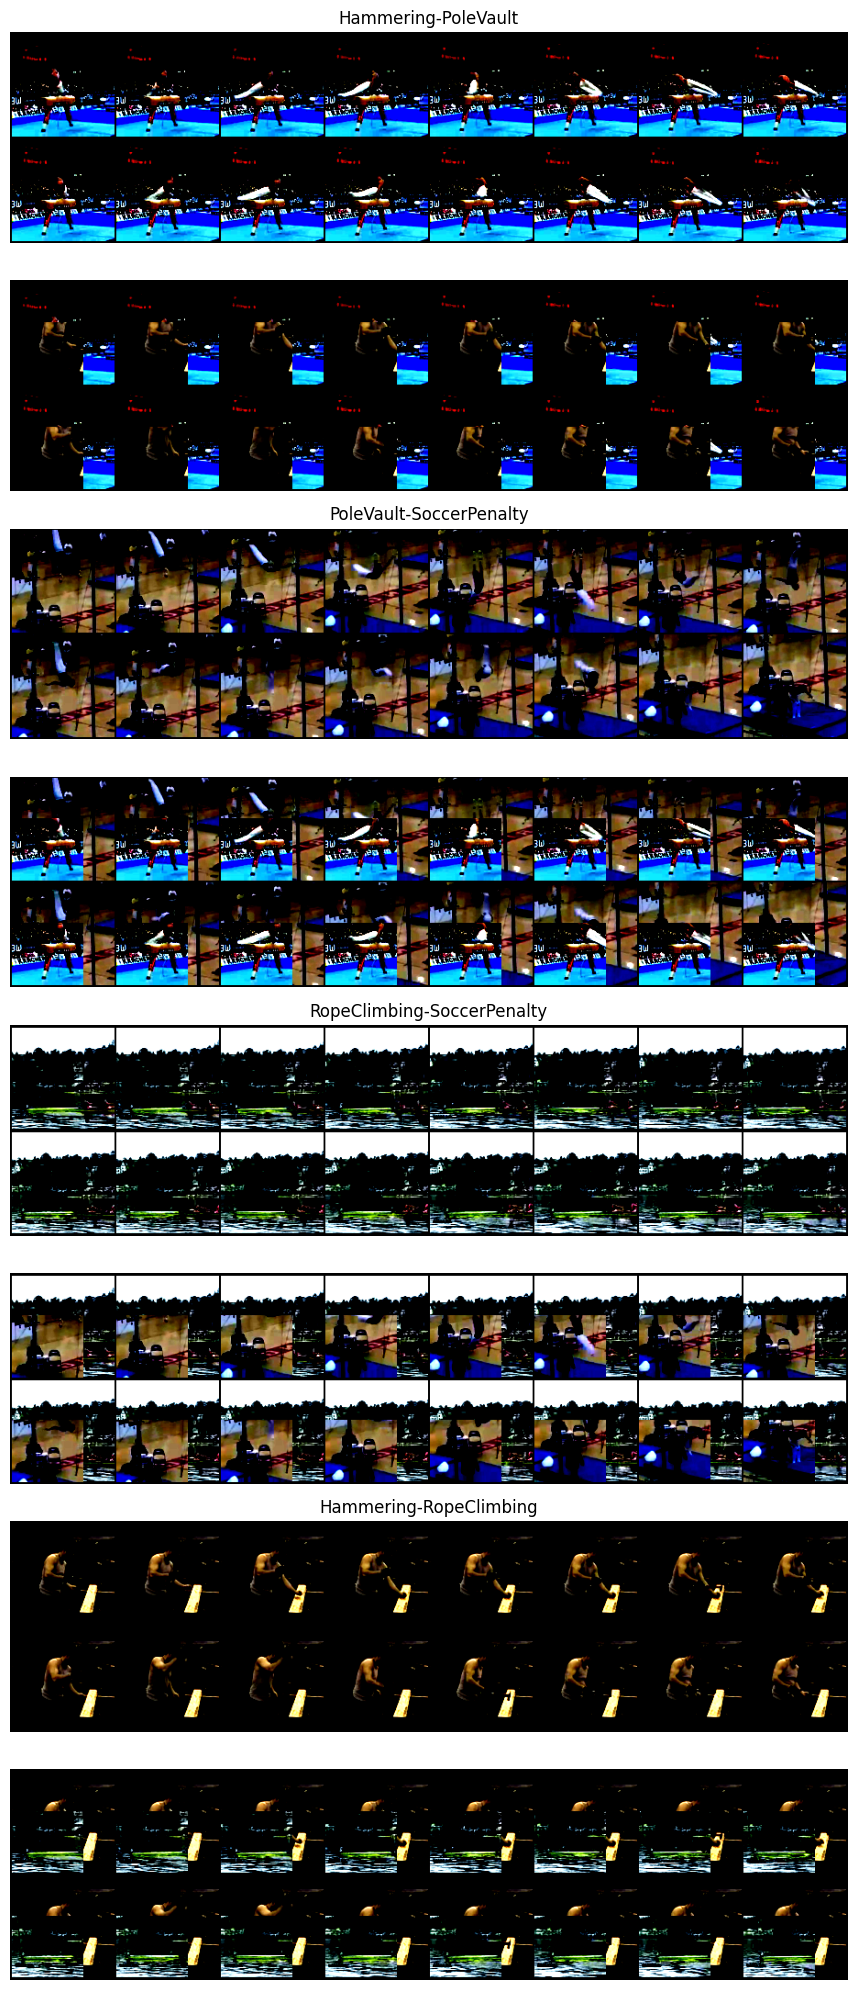

In [45]:
def collate_fn(batch):
    output=default_collate(batch)
    videos=tv_tensors.Video(output[0], dtype=output[0].dtype, device=output[0].device)
    labels=output[1] if len(output)==4 else output[2] # 4 outputs mean there is no audio
    return videos, cutmix(videos, labels), output[-2:]

train_dataloader=DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
original_videos, (video, label), (video_idx, info)=next(iter(train_dataloader))
print(f"{video.shape=}, {video.dtype=} ({video.min().item():.3f},{video.max().item():.3f})")
print(f"{label.shape=},{label.dtype=},({label.min().item():.3f},{label.max().item():.3f})")
print(f"{info=}, {video_idx=}")

_, ax=plt.subplots(2*video.shape[0],1, figsize=(10,20))
for b in range(video.shape[0]): 
    label_ids=torch.nonzero(label[b]>0, as_tuple=True)[0].tolist()
    class_names=[class_ids[l] for l in label_ids]
    ax[2*b].imshow(make_grid(original_videos[b].permute(1,0,2,3)).permute(1,2,0))
    ax[2*b].axis('off')
    ax[2*b].set_title('-'.join(class_names), fontsize=12)
    ax[2*b+1].imshow(make_grid(video[b].permute(1,0,2,3)).permute(1,2,0))
    ax[2*b+1].axis('off')
    # ax[2*b+1].set_title('-'.join(class_names), fontsize=12)
plt.tight_layout()

#### MixUp or CutMix

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.774806..2.873648].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.774806..2.873648].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8951892..2.2953231].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8951892..2.4399045].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8607941..1.9157974].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8607941..1.9157974].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8951892..2

video.shape=torch.Size([4, 3, 16, 112, 112]), video.dtype=torch.float32 (-1.895,2.874)
label.shape=torch.Size([4, 101]),label.dtype=torch.float32,(0.000,1.000)
info={'video_fps': tensor([8, 8, 8, 8])}, video_idx=tensor([5531, 7123, 8129, 5507])


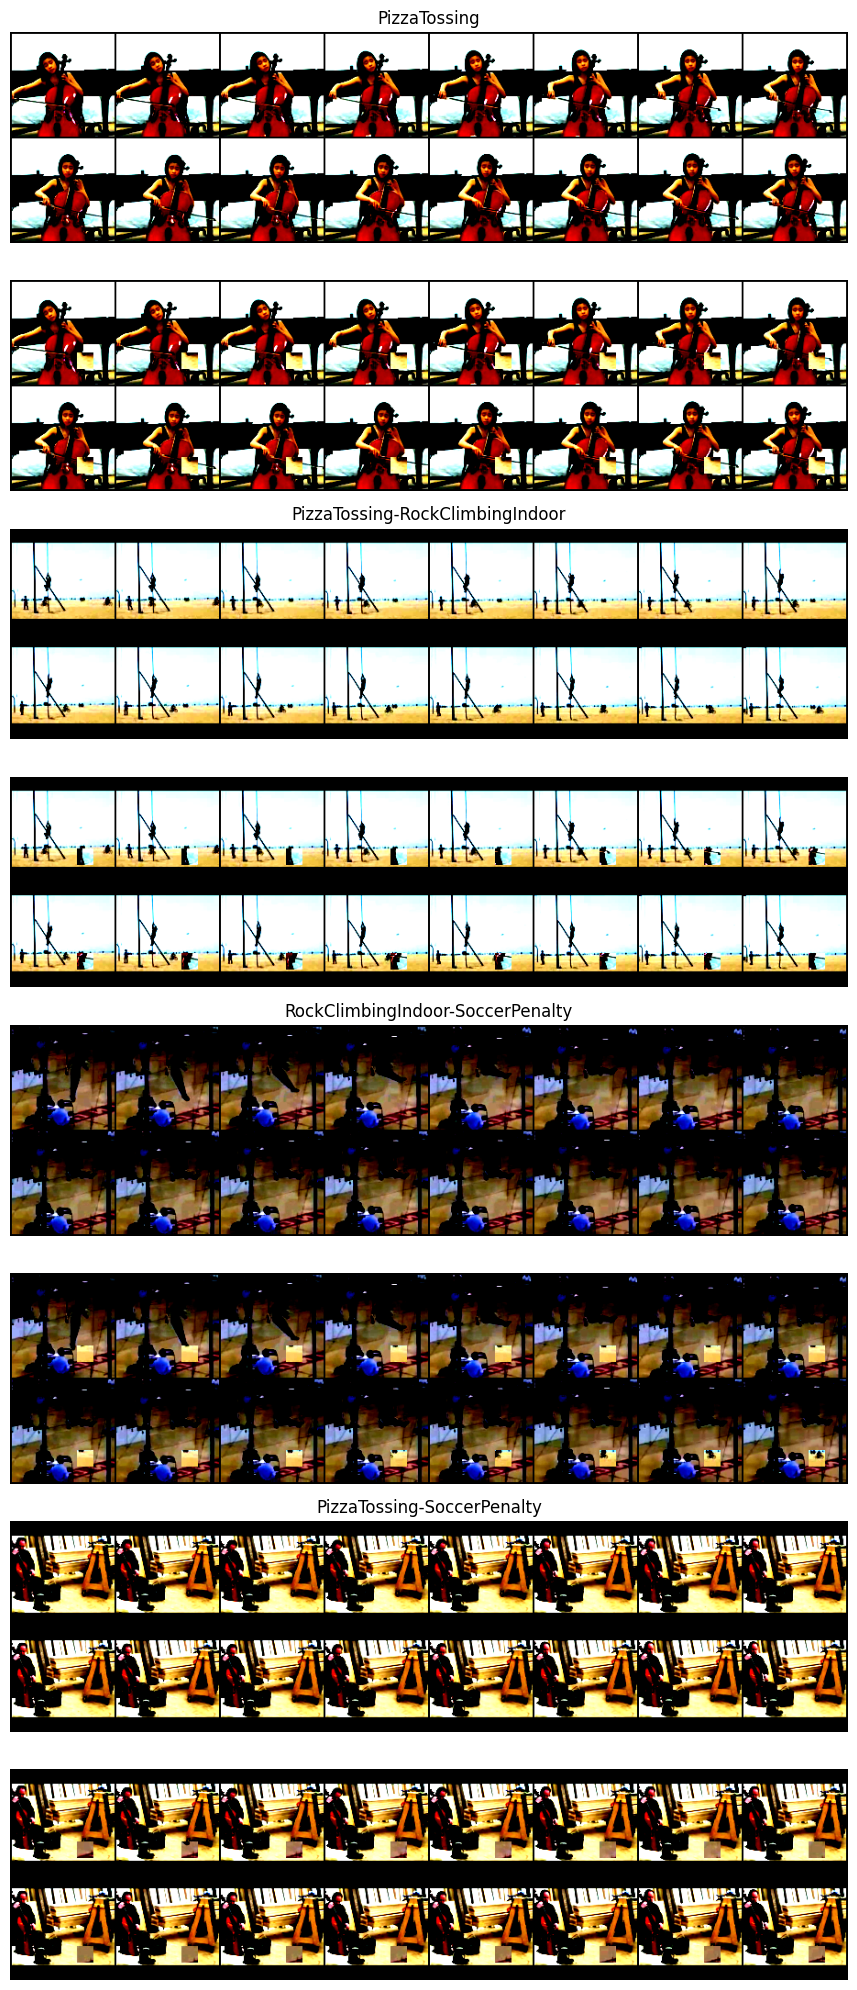

In [48]:
def collate_fn(batch):
    output=default_collate(batch)
    videos=tv_tensors.Video(output[0], dtype=output[0].dtype, device=output[0].device)
    labels=output[1] if len(output)==4 else output[2] # 4 outputs mean there is no audio
    return videos, cutmix_or_mixup(videos, labels), output[-2:]

train_dataloader=DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
original_videos, (video, label), (video_idx, info)=next(iter(train_dataloader))
print(f"{video.shape=}, {video.dtype=} ({video.min().item():.3f},{video.max().item():.3f})")
print(f"{label.shape=},{label.dtype=},({label.min().item():.3f},{label.max().item():.3f})")
print(f"{info=}, {video_idx=}")

_, ax=plt.subplots(2*video.shape[0],1, figsize=(10,20))
for b in range(video.shape[0]): 
    label_ids=torch.nonzero(label[b]>0, as_tuple=True)[0].tolist()
    class_names=[class_ids[l] for l in label_ids]
    ax[2*b].imshow(make_grid(original_videos[b].permute(1,0,2,3)).permute(1,2,0))
    ax[2*b].axis('off')
    ax[2*b].set_title('-'.join(class_names), fontsize=12)
    ax[2*b+1].imshow(make_grid(video[b].permute(1,0,2,3)).permute(1,2,0))
    ax[2*b+1].axis('off')
    # ax[2*b+1].set_title('-'.join(class_names), fontsize=12)
plt.tight_layout()